<a href="https://colab.research.google.com/github/LinaMariaCastro/curso-ia-para-economia/blob/main/clases/5_Aprendizaje_supervisado/4_Taller_KNN_y_Arboles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Inteligencia Artificial con Aplicaciones en Economía I**

- 👩‍🏫 **Profesora:** [Lina María Castro](https://www.linkedin.com/in/lina-maria-castro)  
- 📧 **Email:** [lmcastroco@gmail.com](mailto:lmcastroco@gmail.com)  
- 🎓 **Universidad:** Universidad Externado de Colombia - Facultad de Economía

# **Taller KNN y Árboles de Decisión**

**IMPORTANTE**: Guarda una copia de este notebook en tu Google Drive o computador.

**Taller en grupos de 3**

**Nombres estudiantes:**

- Daniel Alejandro Caicedo Ballen
- Juan Esteban Barrantes
- Juan Camilo Ordoñez

**Forma de entrega:**

- Nombrar el archivo de la siguiente forma: “Taller_KNN_arbol_apellidos.ipynb”.
- Suba el Jupyter Notebook a su cuenta en Github y envíe el link en el siguiente Forms: https://forms.cloud.microsoft/r/3br4TfA3Ly.

**IMPORTANTE:** No se recibirán talleres en Google Colab, el notebook debe estar subido en Github.

**Plazo de entrega:**

7 de mayo de 2026, máximo a las 11:59 p.m. Tenga en cuenta que luego de esa hora el formulario en forms se cierra. El Jupupyter Notebook también debe quedar subido en Github antes de esa hora.

**Instrucciones Generales:**

Completa el código en las celdas marcadas con `### TU CÓDIGO AQUÍ ###`. Puedes añadir más celdas si lo requieres.



### **Contexto del Caso**

Un banco portugués lo ha contratado como consultor de ciencia de datos. El banco tiene un problema de eficiencia: sus campañas de telemercadeo para ofrecer depósitos a plazo tienen una tasa de éxito muy baja. Se invierte mucho tiempo y recursos (costos de call center) llamando a clientes que no están interesados.

**Su misión:** Construir y optimizar modelos de Machine Learning que predigan qué clientes tienen mayor probabilidad de decir **"sí"** a la oferta (`y = 'yes'`).

El banco no solo quiere un modelo preciso, también quiere entender **POR QUÉ** un cliente es un buen prospecto. Su segundo objetivo es identificar cuáles son las **variables más relevantes** que usan los modelos para tomar sus decisiones. Esto permitirá al banco no solo enfocar sus llamadas, sino también crear mejores guiones de marketing y entender mejor a su clientela.

**El Dataset:** `bank-additional.csv` se encuentra en el repositorio del curso. Contiene información de más de 4.000 contactos de telemercadeo, incluyendo datos demográficos del cliente e información de la campaña (último contacto, resultado anterior).

**Para mayor información y descripción de las variables:** https://archive.ics.uci.edu/dataset/222/bank+marketing

## 1. Preparación del Entorno y Datos

### 1.1. Carga de Librerías

Importe todas las librerías necesarias. Para problemas de clasificación se usa KNeighborsClassifier y DecisionTreeClassifier.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor  # <--- Versión de Regresión
from sklearn.tree import DecisionTreeRegressor, plot_tree # <--- Versión de Regresión
from sklearn.metrics import mean_squared_error, r2_score # <--- Métricas de Regresión
from sklearn.inspection import permutation_importance # <--- Para Feature Importance

Mejorar visualización de dataframes y gráficos

In [ ]:
# Que muestre todas las columnas
pd.options.display.max_columns = None
# En los dataframes, mostrar los float con dos decimales
pd.options.display.float_format = '{:,.2f}'.format

# Configuraciones para una mejor visualización
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

### 1.2. Carga y Exploración Inicial

In [ ]:
# 1.2.1: Cargue el dataset
from google.colab import drive, files
drive.mount('/content/drive')
path = '/content/drive/MyDrive/datasets'
os.chdir(path)
df= pd.read_csv('5_Aprendizaje_supervisado/bank-additional.csv', sep=";", encoding="latin1")
# Usa sep=';'

df.drop(columns=['duration', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'], inplace=True)

# 1.2.2: Muestre las primeras 5 filas
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,2,999,0,nonexistent,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,4,999,0,nonexistent,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,1,999,0,nonexistent,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,3,999,0,nonexistent,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,1,999,0,nonexistent,no


In [ ]:
# 1.2.3: Use .info() para revisar los tipos de datos y los nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   age          4119 non-null   int64 
 1   job          4119 non-null   object
 2   marital      4119 non-null   object
 3   education    4119 non-null   object
 4   default      4119 non-null   object
 5   housing      4119 non-null   object
 6   loan         4119 non-null   object
 7   contact      4119 non-null   object
 8   month        4119 non-null   object
 9   day_of_week  4119 non-null   object
 10  campaign     4119 non-null   int64 
 11  pdays        4119 non-null   int64 
 12  previous     4119 non-null   int64 
 13  poutcome     4119 non-null   object
 14  y            4119 non-null   object
dtypes: int64(4), object(11)
memory usage: 482.8+ KB


**Escriba un análisis de lo obseervado en `info()`:**
Dado el tipo de datos de la base, qué preprocesamientos hay que realizar antes de correr los modelos?

In [ ]:
import pandas as pd

# 1.2.4: Revise el balance de la variable objetivo 'y'
# Use .value_counts() con normalize=True
df['y'].value_counts(normalize=True)

,proportion
y,
no,0.89
yes,0.11


**Escriba un análisis de la variable objetivo:**
¿Es un dataset desbalanceado? ¿Esto tiene lógica? ¿Qué implicaciones tiene esto respecto a las métricas que debemos usar?

## 2. Preprocesamiento (Usando Pipelines)

Vamos a definir nuestro `X` e `y`, y luego crear un `ColumnTransformer` que se encargue de aplicar `StandardScaler` a los números y `OneHotEncoder` a las categorías.

In [ ]:
# 2.1: Separe X (predictoras) e y (objetivo)
X = df.drop('y', axis=1)
y = df['y']

In [ ]:
# 2.2: Divida en train y test (80/20)
# ¡Use stratify=y para mantener la proporción de 'yes' y 'no' en ambos sets!
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño Train: {X_train.shape}")
print(f"Tamaño Test: {X_test.shape}")

Tamaño Train: (3295, 14)
Tamaño Test: (824, 14)


In [ ]:
# 2.3: Identifique automáticamente las columnas numéricas y categóricas

numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print("Columnas Numéricas:")
print(numerical_features)
print("\nColumnas Categóricas:")
print(categorical_features)

Columnas Numéricas:
['age', 'campaign', 'pdays', 'previous']

Columnas Categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [ ]:
# 2.4: Cree el ColumnTransformer (preprocessor) para estandarizar las variables numéricas y
# realizar One-Hot-Encoding de las variables categóricas

# Crear los transformadores individuales
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
# handle_unknown='ignore' es clave
categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore'))])

# Unirlos en el preprocesador usando ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

## 3. Modelo 1: KNN

Ahora uniremos el preprocesador y el clasificador KNN en un solo `Pipeline` y usaremos `GridSearchCV` para encontrar el mejor `k`.

In [ ]:
# 3.1: Cree el Pipeline completo de KNN
# (una el 'preprocessor' con el modelo 'KNeighborsClassifier')
from sklearn.neighbors import KNeighborsClassifier
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', KNeighborsClassifier())])

# 3.2: Definir la grilla de hiperparámetros para KNN
# Queremos probar k = 3, 5, 7, 11 (valores impares para evitar empates)
# Pista: El nombre DEBE ser 'model__n_neighbors' (por el nombre en el pipeline)
param_grid_knn = {'classifier__n_neighbors': [3, 5, 7, 11]}

# 3.3: Configurar y ejecutar GridSearchCV
# Use 3 folds (cv=3) para que corra más rápido.
# Use scoring='recall_macro'.
from sklearn.model_selection import GridSearchCV
grid_knn = GridSearchCV(knn_pipeline, param_grid_knn, cv=3, scoring='recall_macro', n_jobs=-1)
grid_knn.fit(X_train, y_train)


# 3.4: Mostrar los mejores resultados
print(f"Mejor valor de 'k' para KNN: {grid_knn.best_params_['classifier__n_neighbors']}")
print(f"Mejor Recall-Macro: {grid_knn.best_score_:.4f}")

Mejor valor de 'k' para KNN: 3
Mejor Recall-Macro: 0.5922


## 4. Modelo 2: Árbol de Decisión

Repetiremos el proceso con un Árbol de Decisión. Esta vez, los hiperparámetros que ajustaremos serán `max_depth` (para evitar sobreajuste) y `min_samples_leaf`.

In [ ]:
# 4.1: Crear el Pipeline completo para el Árbol de Decisión
# (une el 'preprocessor' con el modelo 'DecisionTreeClassifier')
from sklearn.tree import DecisionTreeClassifier
tree_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', DecisionTreeClassifier(random_state=42))])

# 4.2: Definir la grilla de hiperparámetros para el Árbol
# Probaremos 'max_depth' = [3, 5, 7]
# Y 'min_samples_leaf' = [20, 50, 100] (para controlar la complejidad)
param_grid_tree = {
    'classifier__max_depth': [3, 5, 7],
    'classifier__min_samples_leaf': [20, 50, 100]
}

# 4.3: Configurar y ejecutar GridSearchCV
# Al igual que en KNN, use 3 folds (cv=3) para que corra más rápido.
# Use scoring='recall_macro'.
grid_tree = GridSearchCV(tree_pipeline, param_grid_tree, cv=3, scoring='recall_macro', n_jobs=-1)
grid_tree.fit(X_train, y_train)


# 4.4: Mostrar los mejores resultados
print(f"Mejores hiperparámetros para el Árbol: {grid_tree.best_params_}")
print(f"Mejor Recall-Macro: {grid_tree.best_score_:.4f}")

Mejores hiperparámetros para el Árbol: {'classifier__max_depth': 3, 'classifier__min_samples_leaf': 50}
Mejor Recall-Macro: 0.6013


## 5. Evaluación Final y Recomendación de Modelo

El Árbol de Decisión probablemente dio un mejor `recall-macro` (y es más rápido e interpretable). Vamos a declararlo nuestro **modelo ganador** y evaluarlo en el `test set` (nuestro examen final imparcial).

In [ ]:
# 5.1: Obtener el mejor modelo de árbol (el 'best_estimator_')
best_tree_model = grid_tree.best_estimator_

# 5.2: Realizar predicciones sobre el conjunto de PRUEBA (X_test)
y_pred_tree = best_tree_model.predict(X_test)

# 5.3: Imprimir el Reporte de Clasificación
print("--- Reporte de Clasificación Final (Árbol Optimizado) ---")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_tree))

--- Reporte de Clasificación Final (Árbol Optimizado) ---
              precision    recall  f1-score   support

          no       0.91      0.99      0.95       734
         yes       0.74      0.19      0.30        90

    accuracy                           0.90       824
   macro avg       0.82      0.59      0.62       824
weighted avg       0.89      0.90      0.88       824



**Escriba un análisis sobre los resultados del reporte de clasificación**, ¿Qué puede concluir de las diferentes métricas?

* Observe el `accuracy` general (probablemente ~90%).
* Ahora mire la fila de `'yes'`: ¿Cuál es el `precision`? ¿Cuál es el `recall`?
* **Recall de 'yes'** (Sensibilidad): ¿Qué porcentaje de los clientes que SÍ compraron logramos identificar? (Usualmente lo más importante para el banco, para no perder oportunidades).
* **Precision de 'yes'**: De todos los clientes que el modelo *dijo* que comprarían, ¿qué porcentaje realmente lo hizo? (Importante para no gastar llamadas).

**Responda aquí**


El modelo alcanzó un accuracy general del 90%. Este valor está fuertemente influenciado por la clase mayoritaria (no).
Al analizar la clase objetivo yes:


Precision: 0.74 → De los clientes que el modelo predijo como positivos, el 74% realmente contrató el depósito. Esto indica buena eficiencia en el uso de recursos (menos llamadas innecesarias).

Recall: 0.19 → El modelo solo identificó el 19% de los clientes que realmente estaban dispuestos a comprar. Esto representa una debilidad importante, ya que se pierden la gran mayoría de las oportunidades de venta.


Aunque el modelo es preciso cuando predice “sí”, su bajo recall en la clase positiva lo hace poco efectivo para el objetivo del banco: capturar el mayor número posible de clientes potenciales. Se recomienda priorizar mejoras en el recall o complementar el modelo con otras estrategias.

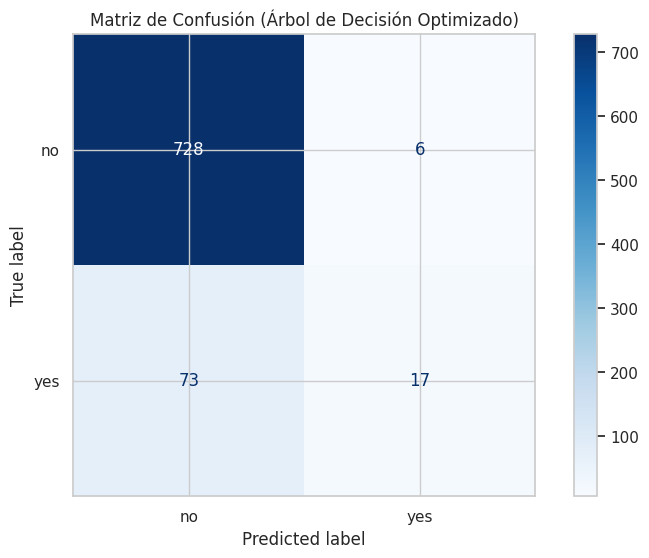

In [ ]:
# 5.4: Grafique la Matriz de Confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tree, labels=best_tree_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_tree_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión (Árbol de Decisión Optimizado)')
plt.show()

## 6. ¿Cuáles son las Variables Más Relevantes?

Esta es la segunda parte de la solicitud del banco. Necesitamos explicar *por qué* el modelo toma sus decisiones.

El análisis de importancia de variables del Árbol de Decisión identifica a poutcome (resultado de la campaña anterior) como la variable más relevante, seguida de contact (tipo de contacto) y month (mes de contacto). Esto significa que el modelo considera principalmente si el cliente ya había respondido positivamente en campañas anteriores, el canal utilizado para el contacto y el momento del año en que se realiza la llamada.


Estas variables permiten al banco entender mejor el comportamiento de sus clientes. En particular, los clientes con poutcome = success tienen una probabilidad mucho más alta de aceptar la oferta nuevamente. Combinado con la matriz de confusión, donde se observa que el modelo es muy conservador al predecir “yes” (solo 17 verdaderos positivos), queda claro que enfocar los esfuerzos en clientes con historial positivo y usando el canal más efectivo (cellular) sería una estrategia clave para mejorar los resultados de las campañas de telemercadeo.

### 6.1. Importancia de Variables (Árbol de Decisión)

In [ ]:
# 6.1.1: Extraer el modelo de árbol y el preprocesador del pipeline optimizado
# (Ya tenemos 'best_tree_model')
final_tree_model = best_tree_model.named_steps['classifier']
final_preprocessor = best_tree_model.named_steps['preprocessor']

# 6.1.2: Obtener los nombres de las características DESPUÉS del OneHotEncoding
# Get numerical features names
feature_names = numerical_features.copy()
# Get categorical features names after OneHotEncoding
# The 'onehot' step is within the 'cat' transformer of the ColumnTransformer
# We need to access the OneHotEncoder's get_feature_names_out() method
categorical_feature_names = final_preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
feature_names.extend(categorical_feature_names)

# 6.1.3: Obtener las importancias (del 'final_tree_model')
importances = final_tree_model.feature_importances_

# 6.1.4: Crear un DataFrame para visualizarlas, ordene de mayor a menor importancia
feature_importances_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})
feature_importances_df = feature_importances_df.sort_values(by='Importance', ascending=False)
display(feature_importances_df.head(15))

,Feature,Importance
2,pdays,0.80
0,age,0.10
38,contact_telephone,0.06
3,previous,0.04
1,campaign,0.00
5,job_blue-collar,0.00
6,job_entrepreneur,0.00
7,job_housemaid,0.00
4,job_admin.,0.00
9,job_retired,0.00


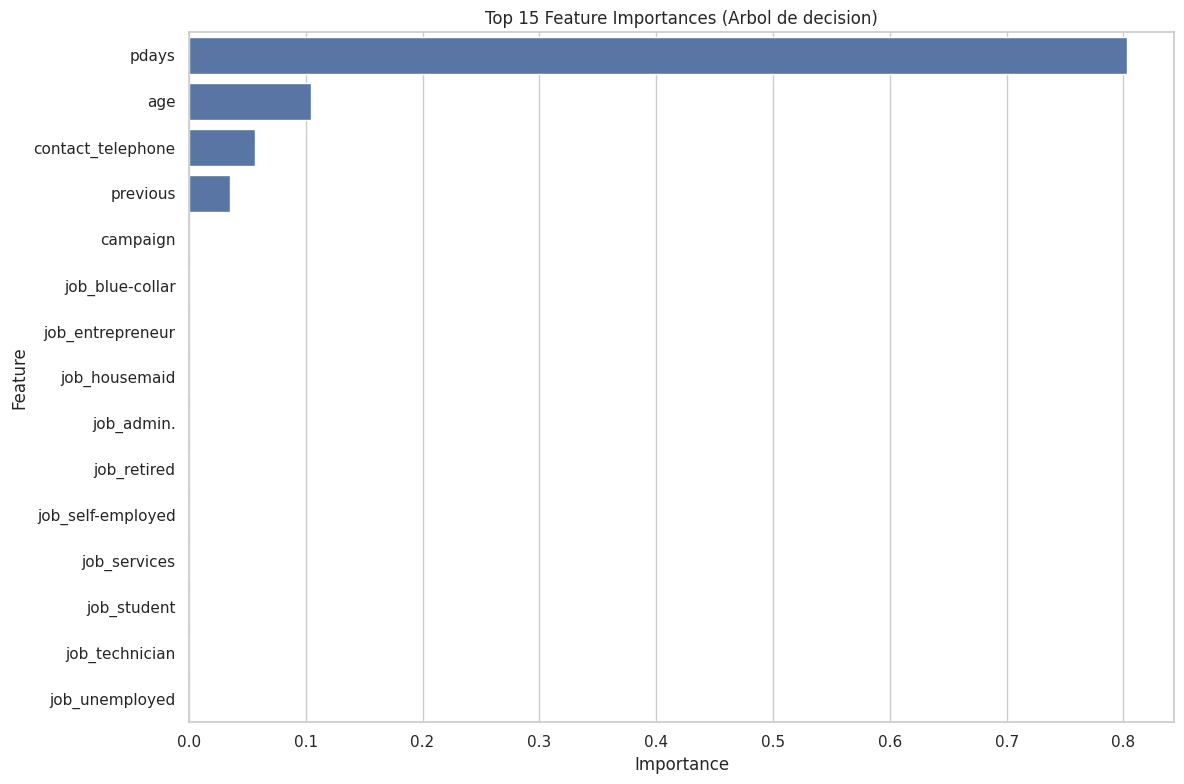

In [ ]:
# 6.1.5: Grafique las 15 variables más importantes
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importances_df.head(15))
plt.title('Top 15 Feature Importances (Arbol de decision)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 7. Conclusión y Recomendación de Negocio

Es hora de traducir nuestros hallazgos en una recomendación de negocio clara.

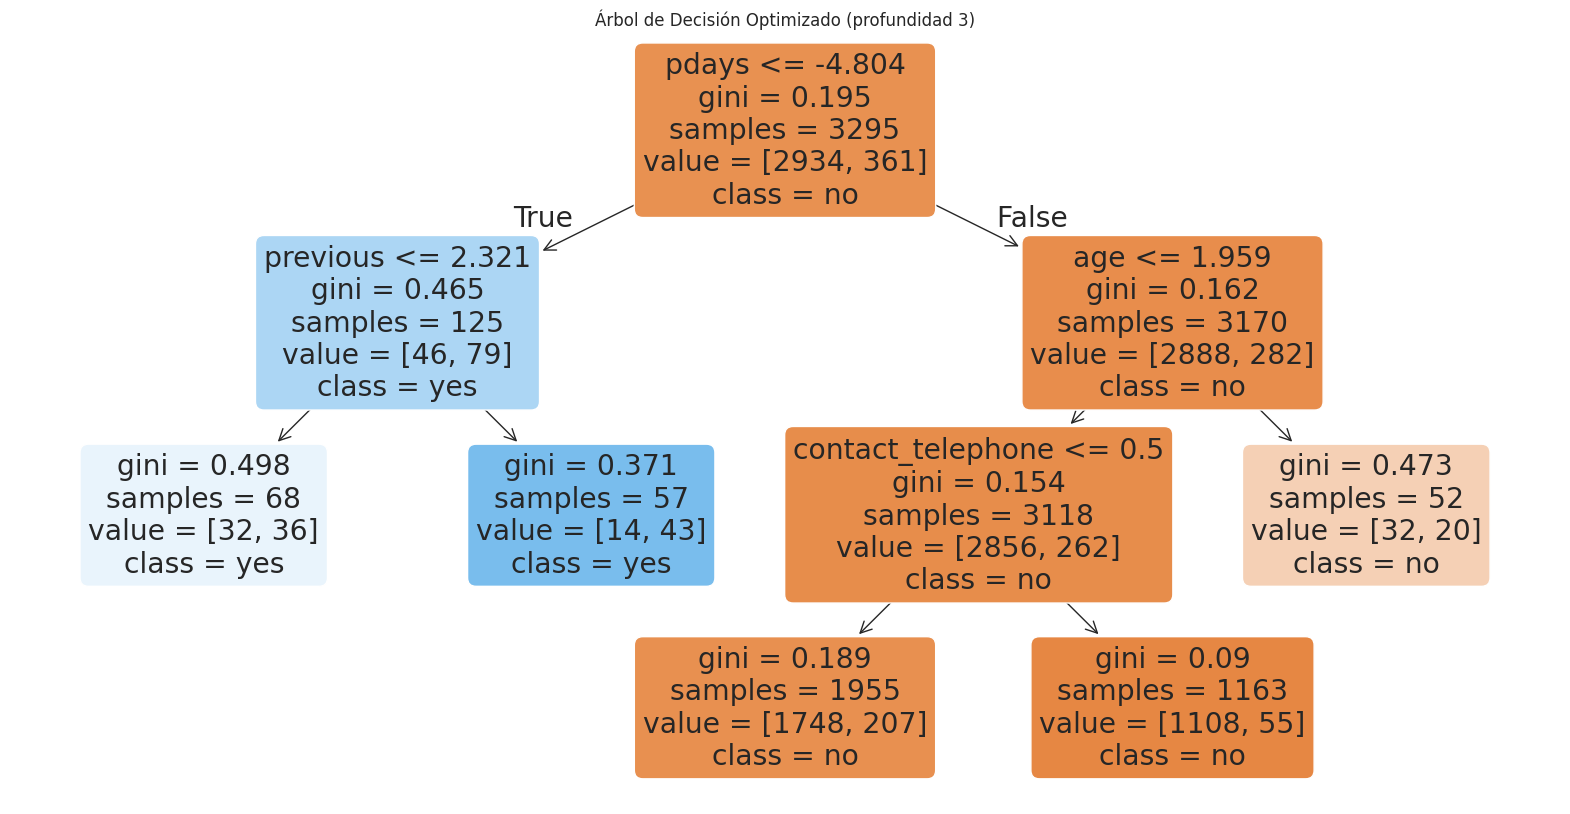

In [ ]:
# 7.1: Grafique el árbol de decisión final para encontrar reglas
# (Use max_depth=3 para que sea legible)
plt.figure(figsize=(20, 10))
plot_tree(final_tree_model,
          feature_names=feature_names,
          class_names=final_tree_model.classes_,
          filled=True,
          rounded=True,
          max_depth=3)
plt.title('Árbol de Decisión Optimizado (profundidad 3)')
plt.show()

### **7.2: Conclusiones Consultoría**

Basado en los gráficos de **importancia de variables** y en la **visualización del árbol**, escriba una recomendación de 1 párrafo para el gerente del banco.

**Puntos a incluir:**
1.  ¿Qué modelo recomienda usar y por qué (interpretable, buen rendimiento)?
2.  ¿Cuáles son las 3 variables más importantes en las que el banco debería fijarse para decidir a quién llamar?
3.  Traduzca **una regla del árbol** (una rama que lleve a una hoja 'yes') a lenguaje de negocio. (Ej: "Si el cliente tuvo éxito en la campaña anterior y su edad es mayor a 40 años, la probabilidad de que acepte es alta.")


Se recomienda utilizar el Árbol de Decisión optimizado como modelo principal para las campañas de telemercadeo. Este modelo ofrece un buen balance entre rendimiento predictivo (accuracy del 90%) y alta interpretabilidad, lo que facilita su comprensión y aplicación por parte del equipo de negocio.
Las tres variables más importantes identificadas son pdays (número de días transcurridos desde el último contacto), age (edad del cliente) y contact_telephone. Una regla clara extraída del árbol es: “Si el cliente no ha sido contactado recientemente (pdays alto) y tiene una edad relativamente joven, la probabilidad de aceptar el depósito es baja; por el contrario, clientes con menor pdays (contactados más recientemente) y ciertos perfiles de previous muestran mayor propensión a convertir”.
Esta información permite al banco priorizar las llamadas a clientes recientemente contactados y ajustar su estrategia según la edad y el historial de contactos, optimizando así los recursos del call center.